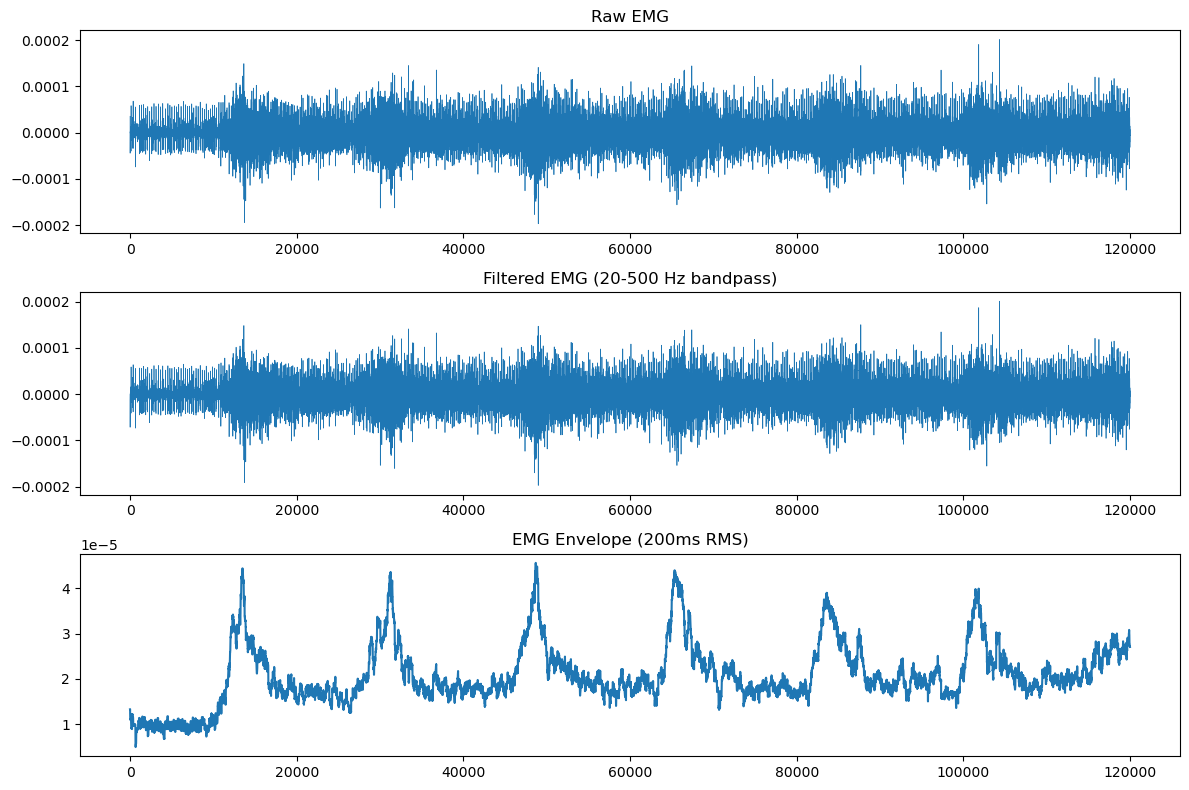

In [ ]:
import sys
sys.path.append('../src')

import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from preprocessing import filter_all_channels, get_envelope
from config import FS

# Load data
data = sio.loadmat('../data/S17_E1_A1.mat')
emg = data['emg']

# Filter all channels
emg_filtered = filter_all_channels(emg)

# Plot comparison - raw vs filtered vs envelope
samples_to_plot = 5 * FS
raw = emg[:, 0]
filtered = emg_filtered[:, 0]
envelope = get_envelope(filtered)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
axes[0].plot(raw[:samples_to_plot], linewidth=0.5)
axes[0].set_title('Raw EMG')
axes[1].plot(filtered[:samples_to_plot], linewidth=0.5)
axes[1].set_title('Filtered EMG (20-500 Hz bandpass)')
axes[2].plot(envelope[:samples_to_plot])
axes[2].set_title('EMG Envelope (200ms RMS)')
plt.tight_layout()
plt.show()